IMH/NHG WiSE 2013–2023 Comparison

Older adult population (aged 60+):

2013 - 517,369

2023 - 838,800

In [64]:
import pandas as pd

In [65]:
dementia_prev=pd.DataFrame({
    "age_group": ["60-74", "75-84", "85+"],
    "2013": [0.034, 0.216, 0.562],
    "2023": [0.030, 0.182, 0.486]
})

In [66]:
demographics=pd.read_csv("../01_demographics/singapore_population_by_age_1950_2100.csv")

In [67]:
demographics["60-74"] = demographics[["60-64", "65-69", "70-74"]].sum(axis=1)

demographics["75-84"] = demographics[["75-79", "80-84"]].sum(axis=1)

demographics["85+"] = demographics[["85-89", "90-94", "95-99", "100+"]].sum(axis=1)

In [68]:
demographics = demographics.melt(
    id_vars=["year"],
    value_vars=["60-74", "75-84", "85+"],
    var_name="age_group",
    value_name="residents"
)

In [69]:
demographics.head()

,year,age_group,residents
0,1950,60-74,29177
1,1951,60-74,30209
2,1952,60-74,31725
3,1953,60-74,33784
4,1954,60-74,36525


In [70]:
demographics.loc[demographics["year"] == 2023]["residents"].sum()

np.int64(1070430)

There is approximately a 200,000 person difference with the population number used by the WiSE study for the year 2023.

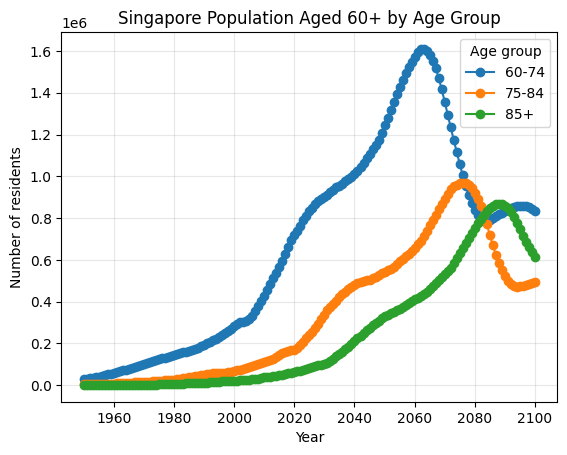

In [71]:
import matplotlib.pyplot as plt

for age_group, group in demographics.groupby("age_group"):
    plt.plot(
        group["year"],
        group["residents"],
        marker="o",
        label=age_group
    )

plt.xlabel("Year")
plt.ylabel("Number of residents")
plt.title("Singapore Population Aged 60+ by Age Group")
plt.legend(title="Age group")
plt.grid(alpha=0.3)

plt.show()

Scenario A — Constant prevalence

2023 age-specific prevalence remains unchanged.

Scenario B — Partial continuation of decline

Only 50% of the 2013–2023 decline continues.

Scenario C — Full continuation of observed decline

The 2013–2023 rate of decline continues.

$$
r = \left(\frac{p_{2023}}{p_{2013}}\right)^{1/10} - 1
$$

In [72]:
# Scenario A: prevalence remains at 2023 levels
prevalence_2023 = {
    "60-74": 0.030,
    "75-84": 0.182,
    "85+": 0.486
}

#Sceniario B & C

prevalence = pd.DataFrame({
    "age_group": ["60-74", "75-84", "85+"],
    "p2013": [0.034, 0.216, 0.562],
    "p2023": [0.030, 0.182, 0.486]
})

# Full observed annual proportional change
prevalence["annual_rate"] = (
    (prevalence["p2023"] / prevalence["p2013"]) ** (1/10)
    - 1
)

# Scenario C: full continuation
for year in [2030, 2050]:
    prevalence[f"C_{year}"] = (
        prevalence["p2023"]
        * (1 + prevalence["annual_rate"]) ** (year - 2023)
    )

# Scenario B: half of observed decline continues
prevalence["partial_rate"] = 0.5 * prevalence["annual_rate"]

for year in [2030, 2050]:
    prevalence[f"B_{year}"] = (
        prevalence["p2023"]
        * (1 + prevalence["partial_rate"]) ** (year - 2023)
    )

full_rate_map = prevalence.set_index("age_group")["annual_rate"]

partial_rate_map = prevalence.set_index("age_group")["partial_rate"]

In [73]:
demographics=demographics[demographics["year"]>=2019]

In [74]:
demographics["prevalence_a"] = (
    demographics["age_group"].map(prevalence_2023)
)
demographics["prevalence_b"] = (
    demographics["age_group"].map(partial_rate_map)
)
demographics["prevalence_c"] = (
    demographics["age_group"].map(full_rate_map)
)

In [75]:
demographics["dementia_cases_a"] = (
    demographics["residents"]
    * demographics["prevalence_a"]
)
demographics["prevalence_b"] = (
    demographics["prevalence_a"]
    * (1 + demographics["prevalence_b"])
      ** (demographics["year"] - 2023)
)
demographics["prevalence_c"] = (
    demographics["prevalence_a"]
    * (1 + demographics["prevalence_c"])
      ** (demographics["year"] - 2023)
)
demographics["dementia_cases_b"] = (
    demographics["residents"]
    * demographics["prevalence_b"]
)
demographics["dementia_cases_c"] = (
    demographics["residents"]
    * demographics["prevalence_c"]
)

In [76]:
demographics.head()

,year,age_group,residents,prevalence_a,prevalence_b,prevalence_c,dementia_cases_a,dementia_cases_b,dementia_cases_c
69,2019,60-74,692954,0.03,0.030758,0.031540,20788.62,21313.912354,21855.901548
70,2020,60-74,719725,0.03,0.030567,0.031148,21591.75,21999.660520,22417.911058
71,2021,60-74,740185,0.03,0.030377,0.030760,22205.55,22484.347662,22768.429064
72,2022,60-74,764150,0.03,0.030188,0.030378,22924.50,23067.963251,23213.233417
73,2023,60-74,789711,0.03,0.030000,0.030000,23691.33,23691.330000,23691.330000


VALIDATION

Singapore dementia prevalence data from (https://worldpopulationreview.com/country-rankings/dementia-rates-by-country)

In [77]:
wpr_prev=pd.DataFrame({
    "year": [2023, 2022, 2021, 2020, 2019],
    "residents": [48760, 44939, 43394, 40809, 38545]
})

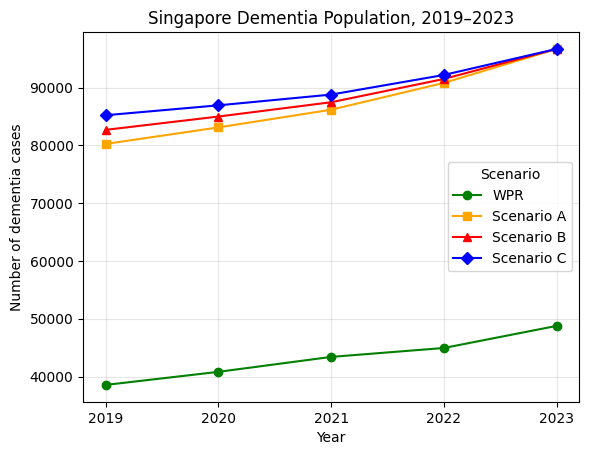

In [78]:
# Restrict to 2019–2023
wpr_plot = wpr_prev[
    wpr_prev["year"].between(2019, 2023)
]

demo_plot = demographics[
    demographics["year"].between(2019, 2023)
]

plt.plot(
    wpr_plot["year"],
    wpr_plot["residents"],
    marker="o",
    label="WPR",
    color="green"
)

plt.plot(
    demo_plot.groupby("year")["dementia_cases_a"].sum(),
    marker="s",
    label="Scenario A",
    color="orange"
)

plt.plot(
    demo_plot.groupby("year")["dementia_cases_b"].sum(),
    marker="^",
    label="Scenario B",
    color="red"
)

plt.plot(
    demo_plot.groupby("year")["dementia_cases_c"].sum(),
    marker="D",
    label="Scenario C",
    color="blue"
)

plt.xlabel("Year")
plt.ylabel("Number of dementia cases")
plt.title("Singapore Dementia Population, 2019–2023")
plt.legend(title="Scenario")
plt.grid(alpha=0.3)

plt.xticks([2019, 2020, 2021, 2022, 2023])

plt.show()

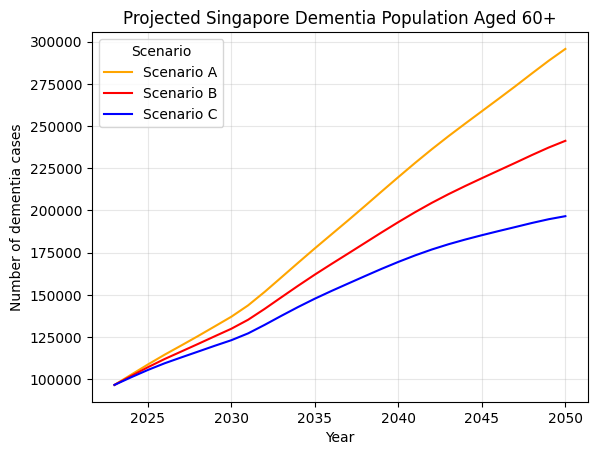

In [79]:
demo_plt = (
    demographics[
        demographics["year"].between(2023, 2050)
    ]
    .groupby("year")[
        ["dementia_cases_a", "dementia_cases_b", "dementia_cases_c"]
    ]
    .sum(min_count=1)
    .reset_index()
)

plt.plot(
    demo_plt["year"],
    demo_plt["dementia_cases_a"],
    label="Scenario A",
    color="orange"
)

plt.plot(
    demo_plt["year"],
    demo_plt["dementia_cases_b"],
    label="Scenario B",
    color="red"
)

plt.plot(
    demo_plt["year"],
    demo_plt["dementia_cases_c"],
    label="Scenario C",
    color="blue"
)

plt.xlabel("Year")
plt.ylabel("Number of dementia cases")
plt.title("Projected Singapore Dementia Population Aged 60+")
plt.legend(title="Scenario")
plt.grid(alpha=0.3)

plt.show()

In [80]:
demo_plt[
    demo_plt["year"].isin([2023, 2030, 2050])
]

,year,dementia_cases_a,dementia_cases_b,dementia_cases_c
0,2023,96694.204,96694.204000,96694.204000
7,2030,137086.842,129970.269839,123176.959208
27,2050,295653.236,241236.818727,196615.160481


In 2023, there were about 74,000 persons living with dementia, based on the second WISE (Well-being of the Singapore Elderly) Study by the Institute of Mental Health.  We estimate this will grow to 152,000 by 2030.

In [83]:
demographics.loc[
    demographics["year"] == 2023,
    ["dementia_cases_a", "dementia_cases_b", "dementia_cases_c"]
].sum()

dementia_cases_a    96694.204
dementia_cases_b    96694.204
dementia_cases_c    96694.204
dtype: float64

In [82]:
demographics.loc[
    demographics["year"] == 2030,
    ["dementia_cases_a", "dementia_cases_b", "dementia_cases_c"]
].sum()

dementia_cases_a    137086.842000
dementia_cases_b    129970.269839
dementia_cases_c    123176.959208
dtype: float64